In [1]:
# notebook to parse the Finucane GTEx fine mapping data for an external eQTL comparison

In [1]:
# import packages
import pandas as pd
import os
from collections import Counter
import seaborn as sns
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib

In [2]:
# open finemapping data
fineMapping_all = pd.read_csv('../raw_data/finucane_fine_mapping/GTEx_49tissues_release1.tsv', sep = '\t')

In [3]:
# filter for credible set variants
credibleSets_all = fineMapping_all[fineMapping_all['cs_id'] != -1]

In [4]:
# filter for SUSIE credible sets
credibleSets_susie = credibleSets_all[credibleSets_all['method'] == 'SUSIE']

In [8]:
credibleSets_all['cohort'].unique()

array(['GTEx'], dtype=object)

In [6]:
credibleSets_susie['cohort'].unique()

array(['GTEx'], dtype=object)

In [5]:
# filter for high pip variants (> 0.9)
highPIP_cs_susie = credibleSets_susie[credibleSets_susie['pip'] >= 0.9]
# filter for low pip (< 0.01) for an auprc/analysis if desired
lowPIP_cs_susie = credibleSets_susie[credibleSets_susie['pip'] < 0.01]

In [6]:
# filter highPIP variants for closest (stretch) tissue type to...
# k562
highPIP_cs_susie_wholeBlood = highPIP_cs_susie[highPIP_cs_susie['tissue'] == 'Whole_Blood']
print(f'there are {len(highPIP_cs_susie_wholeBlood)} Whole Blood variants with PIP >= 0.9')
# hepg2
highPIP_cs_susie_Liver = highPIP_cs_susie[highPIP_cs_susie['tissue'] == 'Liver']
print(f'there are {len(highPIP_cs_susie_Liver)} Liver variants with PIP >= 0.9')
# sknsh
highPIP_cs_susie_Brain = highPIP_cs_susie[highPIP_cs_susie['tissue'].isin([i for i in highPIP_cs_susie['tissue'].unique() if 'Brain' in i])]
print(f'there are {len(highPIP_cs_susie_Brain)} Brain-ish variants with PIP >= 0.9')

there are 2222 Whole Blood variants with PIP >= 0.9
there are 430 Liver variants with PIP >= 0.9
there are 6745 Brain-ish variants with PIP >= 0.9


In [7]:
highPIP_cs_susie.head()

,chromosome,start,end,variant,variant_hg38,allele1,allele2,minor_allele,cohort,method,tissue,gene,maf,beta_marginal,se_marginal,z,pip,cs_id,beta_posterior,sd_posterior
118,chr1,14676.0,14677.0,chr1_14677_G_A,chr1_14677_G_A_b38,G,A,A,GTEx,SUSIE,Adipose_Subcutaneous,ENSG00000228327.3,0.051635,0.742337,0.090654,8.188666,1.000000,1,0.622146,0.082660
119,chr1,14676.0,14677.0,chr1_14677_G_A,chr1_14677_G_A_b38,G,A,A,GTEx,SUSIE,Adipose_Visceral_Omentum,ENSG00000228327.3,0.052239,0.889035,0.112513,7.901620,1.000000,1,0.820819,0.103464
120,chr1,14676.0,14677.0,chr1_14677_G_A,chr1_14677_G_A_b38,G,A,A,GTEx,SUSIE,Adipose_Visceral_Omentum,ENSG00000228463.9,0.052239,-0.901493,0.120957,-7.453004,0.993733,3,-0.554541,0.113523
121,chr1,14676.0,14677.0,chr1_14677_G_A,chr1_14677_G_A_b38,G,A,A,GTEx,SUSIE,Adipose_Visceral_Omentum,ENSG00000241860.6,0.052239,0.955911,0.148454,6.439106,0.999992,1,0.932898,0.146522
123,chr1,14676.0,14677.0,chr1_14677_G_A,chr1_14677_G_A_b38,G,A,A,GTEx,SUSIE,Artery_Tibial,ENSG00000228327.3,0.045377,0.445997,0.077370,5.764432,0.999992,2,0.444741,0.068608


In [8]:
# group high pip variants to get average beta across tissues - use multiple levels to account for effects at different genes
# i think i'm going to drop variants with multiple gene associations because we only have one output?
# maybe?
### tissue agnostic ###
# beta posterior
highPIP_cs_susie_mean_betaPosterior_allTissues = highPIP_cs_susie.filter(['variant_hg38', 'tissue', 'gene', 'pip', 'beta_posterior']).groupby(['variant_hg38', 'gene'])[['beta_posterior']].mean().reset_index()
# beta marginal
highPIP_cs_susie_mean_betaMarginal_allTissues = highPIP_cs_susie.filter(['variant_hg38', 'tissue', 'gene', 'pip', 'beta_marginal']).groupby(['variant_hg38', 'gene'])[['beta_marginal']].mean().reset_index()
### whole blood ###
# beta posterior
highPIP_cs_susie_mean_betaPosterior_WholeBlood = highPIP_cs_susie_wholeBlood.filter(['variant_hg38', 'tissue', 'gene', 'pip', 'beta_posterior']).groupby(['variant_hg38', 'gene'])[['beta_posterior']].mean().reset_index()
# beta marginal
highPIP_cs_susie_mean_betaMarginal_WholeBlood = highPIP_cs_susie_wholeBlood.filter(['variant_hg38', 'tissue', 'gene', 'pip', 'beta_marginal']).groupby(['variant_hg38', 'gene'])[['beta_marginal']].mean().reset_index()
### liver ###
# beta posterior
highPIP_cs_susie_mean_betaPosterior_Liver = highPIP_cs_susie_Liver.filter(['variant_hg38', 'tissue', 'gene', 'pip', 'beta_posterior']).groupby(['variant_hg38', 'gene'])[['beta_posterior']].mean().reset_index()
# beta marginal
highPIP_cs_susie_mean_betaMarginal_Liver = highPIP_cs_susie_Liver.filter(['variant_hg38', 'tissue', 'gene', 'pip', 'beta_marginal']).groupby(['variant_hg38', 'gene'])[['beta_marginal']].mean().reset_index()
### brain ###
# beta posterior
highPIP_cs_susie_mean_betaPosterior_Brain = highPIP_cs_susie_Brain.filter(['variant_hg38', 'tissue', 'gene', 'pip', 'beta_posterior']).groupby(['variant_hg38', 'gene'])[['beta_posterior']].mean().reset_index()
# beta marginal
highPIP_cs_susie_mean_betaMarginal_Brain = highPIP_cs_susie_Brain.filter(['variant_hg38', 'tissue', 'gene', 'pip', 'beta_marginal']).groupby(['variant_hg38', 'gene'])[['beta_marginal']].mean().reset_index()

In [9]:
# make counters of each variant ID in the high PIP filtered sets
# we'll filter for unique IDs, ie variants that only have one gene association
# all tissues
highPIP_all_counter = Counter(highPIP_cs_susie_mean_betaPosterior_allTissues['variant_hg38'])
highPIP_all_singleGenes = [i for i in highPIP_all_counter.keys() if highPIP_all_counter.get(i) == 1]
# whole blood
highPIP_blood_counter = Counter(highPIP_cs_susie_mean_betaPosterior_WholeBlood['variant_hg38'])
highPIP_blood_singleGenes = [i for i in highPIP_blood_counter.keys() if highPIP_blood_counter.get(i) == 1]
# liver
highPIP_liver_counter = Counter(highPIP_cs_susie_mean_betaPosterior_Liver['variant_hg38'])
highPIP_liver_singleGenes = [i for i in highPIP_liver_counter.keys() if highPIP_liver_counter.get(i) == 1]
# brain
highPIP_brain_counter = Counter(highPIP_cs_susie_mean_betaPosterior_Brain['variant_hg38'])
highPIP_brain_singleGenes = [i for i in highPIP_brain_counter.keys() if highPIP_brain_counter.get(i) == 1]

In [10]:
# print some summaries so that you can remember something for a change
print(f'there are {len(highPIP_all_singleGenes)} variants in All tissues with PIP >= 0.9 and only one associated gene')
print(f'there are {len(highPIP_blood_singleGenes)} variants in Whole Blood with PIP >= 0.9 and only one associated gene')
print(f'there are {len(highPIP_liver_singleGenes)} variants in Liver with PIP >= 0.9 and only one associated gene')
print(f'there are {len(highPIP_brain_singleGenes)} variants in any brain tissue with PIP >= 0.9 and only one associated gene')

there are 17198 variants in All tissues with PIP >= 0.9 and only one associated gene
there are 1857 variants in Whole Blood with PIP >= 0.9 and only one associated gene
there are 362 variants in Liver with PIP >= 0.9 and only one associated gene
there are 2512 variants in any brain tissue with PIP >= 0.9 and only one associated gene


In [11]:
# filter the averaged datasets for only those variants with unique gene associations
# all tissues
highPIP_cs_susie_mean_betaPosterior_allTissues_singleFilter = highPIP_cs_susie_mean_betaPosterior_allTissues[highPIP_cs_susie_mean_betaPosterior_allTissues['variant_hg38'].isin(highPIP_all_singleGenes)]
# whole blood
highPIP_cs_susie_mean_betaPosterior_WholeBlood_singleFilter = highPIP_cs_susie_mean_betaPosterior_WholeBlood[highPIP_cs_susie_mean_betaPosterior_WholeBlood['variant_hg38'].isin(highPIP_blood_singleGenes)]
# liver
highPIP_cs_susie_mean_betaPosterior_Liver_singleFilter = highPIP_cs_susie_mean_betaPosterior_Liver[highPIP_cs_susie_mean_betaPosterior_Liver['variant_hg38'].isin(highPIP_liver_singleGenes)]
# brain
highPIP_cs_susie_mean_betaPosterior_Brain_singleFilter = highPIP_cs_susie_mean_betaPosterior_Brain[highPIP_cs_susie_mean_betaPosterior_Brain['variant_hg38'].isin(highPIP_brain_singleGenes)]

In [12]:
# make a dictionary of variant ID and beta posterior
# all tissues
allTissues_beta_dict = dict(zip(highPIP_cs_susie_mean_betaPosterior_allTissues['variant_hg38'], highPIP_cs_susie_mean_betaPosterior_allTissues['beta_posterior']))
# whole blood
wholeBlood_beta_dict = dict(zip(highPIP_cs_susie_mean_betaPosterior_WholeBlood['variant_hg38'], highPIP_cs_susie_mean_betaPosterior_WholeBlood['beta_posterior']))
# liver
liver_beta_dict = dict(zip(highPIP_cs_susie_mean_betaPosterior_Liver['variant_hg38'], highPIP_cs_susie_mean_betaPosterior_Liver['beta_posterior']))
# brain
brain_beta_dict = dict(zip(highPIP_cs_susie_mean_betaPosterior_Brain['variant_hg38'], highPIP_cs_susie_mean_betaPosterior_Brain['beta_posterior']))

In [13]:
# open all promoter predictions
promoter_preds_df = pd.read_csv('../processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut.tsv', sep = '\t')
# add mean mpac skew :/
promoter_preds_df.loc[:, 'mpac_mean_skew'] = [np.mean([k,h,s]) for k,h,s in zip(promoter_preds_df['k562_skew_pred'], promoter_preds_df['hepg2_skew_pred'], promoter_preds_df['sknsh_skew_pred'])]
# add max mpac skew
promoter_preds_df.loc[:, 'mpac_max_skew'] = [max([k,h,s], key=abs) for k,h,s in zip(promoter_preds_df['k562_skew_pred'], promoter_preds_df['hepg2_skew_pred'], promoter_preds_df['sknsh_skew_pred'])]
# add max parm skew
promoter_preds_df.loc[:, 'parm_max_skew'] = [max([k,h], key=abs) for k,h in zip(promoter_preds_df['parm_k562_pred'], promoter_preds_df['parm_hepg2_pred'])]
# add mean parm skew
promoter_preds_df.loc[:, 'parm_mean_skew'] = [np.mean([k,h]) for k,h in zip(promoter_preds_df['parm_k562_pred'], promoter_preds_df['parm_hepg2_pred'])]
# add ID for merging wth phyloP scores
promoter_preds_df.loc[:, 'var_id'] = [(':').join([chrom, str(pos), ref, alt]) for chrom, pos, ref, alt in zip(promoter_preds_df['chrom'], promoter_preds_df['pos'], promoter_preds_df['ref'], promoter_preds_df['alt'])]
# open phyloP annotated variants and add phyloP scores
phylo470 = pd.read_csv('../processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut4.phyloP.annotated.vcf', sep = '\t', comment = '#', header = None)
# drop missing values
phylo470 = phylo470[phylo470[7] != '.']
# build dictionary for adding 
phylo470_dict = dict(zip([(':').join([chrom, str(pos), ref, alt])for chrom, pos, ref, alt in zip(phylo470[0], 
                                                                                                 phylo470[1], 
                                                                                                 phylo470[3], 
                                                                                                 phylo470[4])],
                     [float(i.split('=')[-1]) for i in phylo470[7]]))
# add 470-way phyloP score
promoter_preds_df.loc[:, 'phyloP_470'] = [phylo470_dict.get(i) for i in promoter_preds_df['var_id']]
# first lets do all correlations at the nucleotide level
# some positions are NAs in promoterAI, we will drop those for this analysis
# we'll also drop those predictions without phyloP scores
# filter for those
promoterAI_filtered_preds = promoter_preds_df.dropna()
# add a gtex id to the promoter preds
promoterAI_filtered_preds.loc[:,'gtex_id'] = [f'{('_').join([chrom, str(pos), ref, alt])}_b38' for chrom, pos, ref, alt in zip(promoterAI_filtered_preds['chrom'],
                                                                                                                             promoterAI_filtered_preds['pos'],
                                                                                                                             promoterAI_filtered_preds['ref'],
                                                                                                                             promoterAI_filtered_preds['alt'])]
print(len(promoterAI_filtered_preds))

11886648


/tmp/ipykernel_4033369/186369067.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  promoterAI_filtered_preds.loc[:,'gtex_id'] = [f'{('_').join([chrom, str(pos), ref, alt])}_b38' for chrom, pos, ref, alt in zip(promoterAI_filtered_preds['chrom'],


In [66]:
# scale non promoterAI predictions with tanh
k = 2.5
# mpac #
promoterAI_filtered_preds.loc[:, 'k562_skew_pred_tanh'] = np.tanh(promoterAI_filtered_preds['k562_skew_pred'] / k)
promoterAI_filtered_preds.loc[:, 'hepg2_skew_pred_tanh'] = np.tanh(promoterAI_filtered_preds['hepg2_skew_pred'] / k)
promoterAI_filtered_preds.loc[:, 'sknsh_skew_pred_tanh'] = np.tanh(promoterAI_filtered_preds['sknsh_skew_pred'] / k)
promoterAI_filtered_preds.loc[:, 'mpac_mean_skew_tanh'] = np.tanh(promoterAI_filtered_preds['mpac_mean_skew'] / k)
# parm #
promoterAI_filtered_preds.loc[:, 'parm_k562_pred_tanh'] = np.tanh(promoterAI_filtered_preds['parm_k562_pred'] / k)
promoterAI_filtered_preds.loc[:, 'parm_hepg2_pred_tanh'] = np.tanh(promoterAI_filtered_preds['parm_hepg2_pred'] / k)
promoterAI_filtered_preds.loc[:, 'parm_mean_skew_tanh'] = np.tanh(promoterAI_filtered_preds['parm_mean_skew'] / k)

In [14]:
# filter the predictions for each set
# all tissues
highPIP_all_tissue_preds = promoterAI_filtered_preds[promoterAI_filtered_preds['gtex_id'].isin(highPIP_all_singleGenes)]
# whole blood
highPIP_whole_blood_preds = promoterAI_filtered_preds[promoterAI_filtered_preds['gtex_id'].isin(highPIP_blood_singleGenes)]
# liver
highPIP_liver_preds = promoterAI_filtered_preds[promoterAI_filtered_preds['gtex_id'].isin(highPIP_liver_singleGenes)]
# brain
highPIP_brain_preds = promoterAI_filtered_preds[promoterAI_filtered_preds['gtex_id'].isin(highPIP_brain_singleGenes)]

In [15]:
# add betas to each df
highPIP_all_tissue_preds.loc[:, 'beta_posterior'] = [allTissues_beta_dict.get(i) for i in highPIP_all_tissue_preds['gtex_id']]
highPIP_whole_blood_preds.loc[:, 'beta_posterior'] = [wholeBlood_beta_dict.get(i) for i in highPIP_whole_blood_preds['gtex_id']]
highPIP_liver_preds.loc[:, 'beta_posterior'] = [liver_beta_dict.get(i) for i in highPIP_liver_preds['gtex_id']]
highPIP_brain_preds.loc[:, 'beta_posterior'] = [brain_beta_dict.get(i) for i in highPIP_brain_preds['gtex_id']]

/tmp/ipykernel_4033369/2006315053.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  highPIP_all_tissue_preds.loc[:, 'beta_posterior'] = [allTissues_beta_dict.get(i) for i in highPIP_all_tissue_preds['gtex_id']]
/tmp/ipykernel_4033369/2006315053.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  highPIP_whole_blood_preds.loc[:, 'beta_posterior'] = [wholeBlood_beta_dict.get(i) for i in highPIP_whole_blood_preds['gtex_id']]
/tmp/ipykernel_4033369/2006315053.py:4: SettingWithCopyWarning: 
A value is trying t

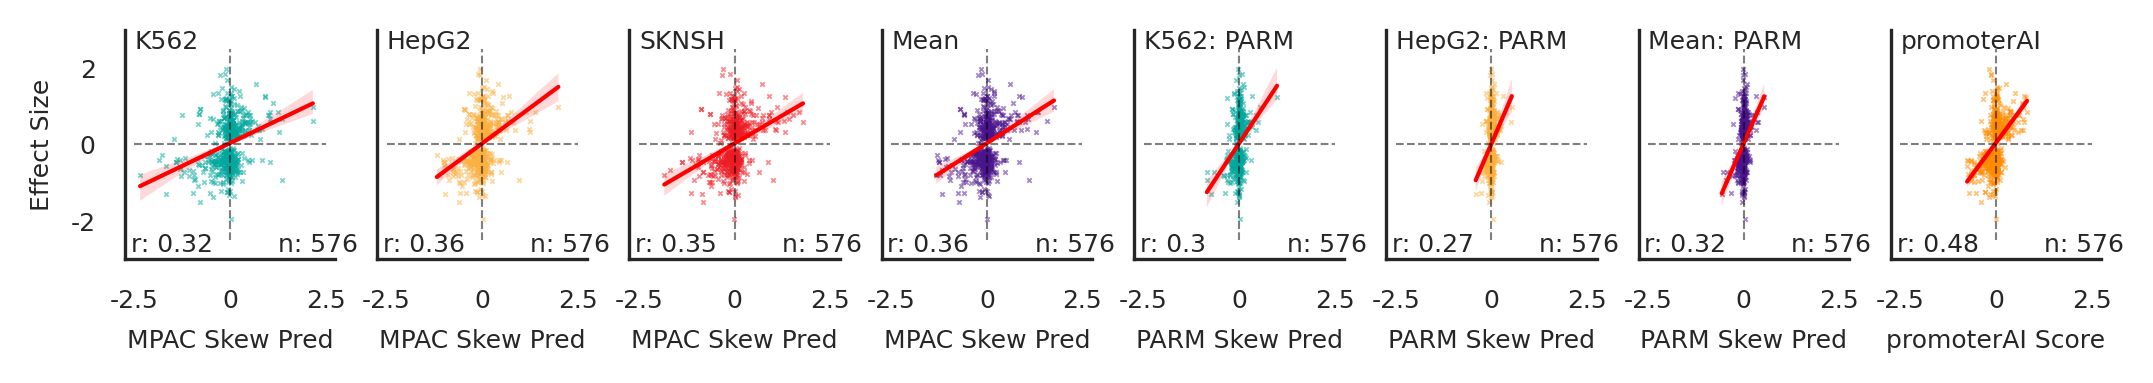

In [20]:
# plot all tissue variants
f = plt.figure(figsize=(8.5,2),dpi=300)
gs = f.add_gridspec(1,8)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# k562 #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_aspect('equal')
    sns.regplot(data=highPIP_all_tissue_preds, x='k562_skew_pred', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='#00A79D',
                alpha=0.5))
    ax_01.set_ylabel('Effect Size', fontsize = 6)
    ax_01.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_01.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_01.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['k562_skew_pred'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('K562', xy=(-2.5, 2.5), fontsize = 6)
# hepg2 #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_aspect('equal')
    sns.regplot(data=highPIP_all_tissue_preds, x='hepg2_skew_pred', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='#FBB040',
                alpha=0.5))
    ax_02.set_ylabel('')
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_02.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['hepg2_skew_pred'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('HepG2', xy=(-2.5, 2.5), fontsize = 6)
# sknsh #
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_03.set_aspect('equal')
    sns.regplot(data=highPIP_all_tissue_preds, x='sknsh_skew_pred', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='#ED1C24',
                alpha=0.5))
    ax_03.set_ylabel('')
    ax_03.tick_params(labelleft=False)
    ax_03.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_03.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['sknsh_skew_pred'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('SKNSH', xy=(-2.5, 2.5), fontsize = 6)
# mean
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[0,3], sharey=ax_01)
    ax_04.set_aspect('equal')
    sns.regplot(data=highPIP_all_tissue_preds, x='mpac_mean_skew', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='#4A148C',
                alpha=0.5))
    ax_04.set_ylabel('')
    ax_04.tick_params(labelleft=False)
    ax_04.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_04.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['mpac_mean_skew'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('Mean', xy=(-2.5, 2.5), fontsize = 6)
# k562 parm #
with sns.axes_style('white'):
    ax_05 = f.add_subplot(gs[0,4], sharey=ax_01)
    ax_05.set_aspect('equal')
    sns.regplot(data=highPIP_all_tissue_preds, x='parm_k562_pred', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='#00A79D',
                alpha=0.5))
    ax_05.set_ylabel('')
    ax_05.tick_params(labelleft=False)
    ax_05.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_05.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_05.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_k562_pred'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('K562: PARM', xy=(-2.5, 2.5), fontsize = 6)
# hepg2 parm #
with sns.axes_style('white'):
    ax_06 = f.add_subplot(gs[0,5], sharey=ax_01)
    ax_06.set_aspect('equal')
    sns.regplot(data=highPIP_all_tissue_preds, x='parm_hepg2_pred', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='#FBB040',
                alpha=0.5))
    ax_06.set_ylabel('')
    ax_06.tick_params(labelleft=False)
    ax_06.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_06.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_06.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_hepg2_pred'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('HepG2: PARM', xy=(-2.5, 2.5), fontsize = 6)
# mean parm #
with sns.axes_style('white'):
    ax_07 = f.add_subplot(gs[0,6], sharey=ax_01)
    ax_07.set_aspect('equal')
    sns.regplot(data=highPIP_all_tissue_preds, x='parm_mean_skew', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='#4A148C',
                alpha=0.5))
    ax_07.set_ylabel('')
    ax_07.tick_params(labelleft=False)
    ax_07.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_07.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_07.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_mean_skew'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('Mean: PARM', xy=(-2.5, 2.5), fontsize = 6)
# promoterAI #
with sns.axes_style('white'):
    ax_08 = f.add_subplot(gs[0,7], sharey=ax_01)
    ax_08.set_aspect('equal')
    sns.regplot(data=highPIP_all_tissue_preds, x='promoterAI_score', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='darkorange',
                alpha=0.5)
        )
    ax_08.set_ylabel('')
    ax_08.tick_params(labelleft=False)
    ax_08.set_xlabel('promoterAI Score', fontsize = 6)
    ax_08.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_08.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['promoterAI_score'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('promoterAI', xy=(-2.5, 2.5), fontsize = 6)
sns.despine()

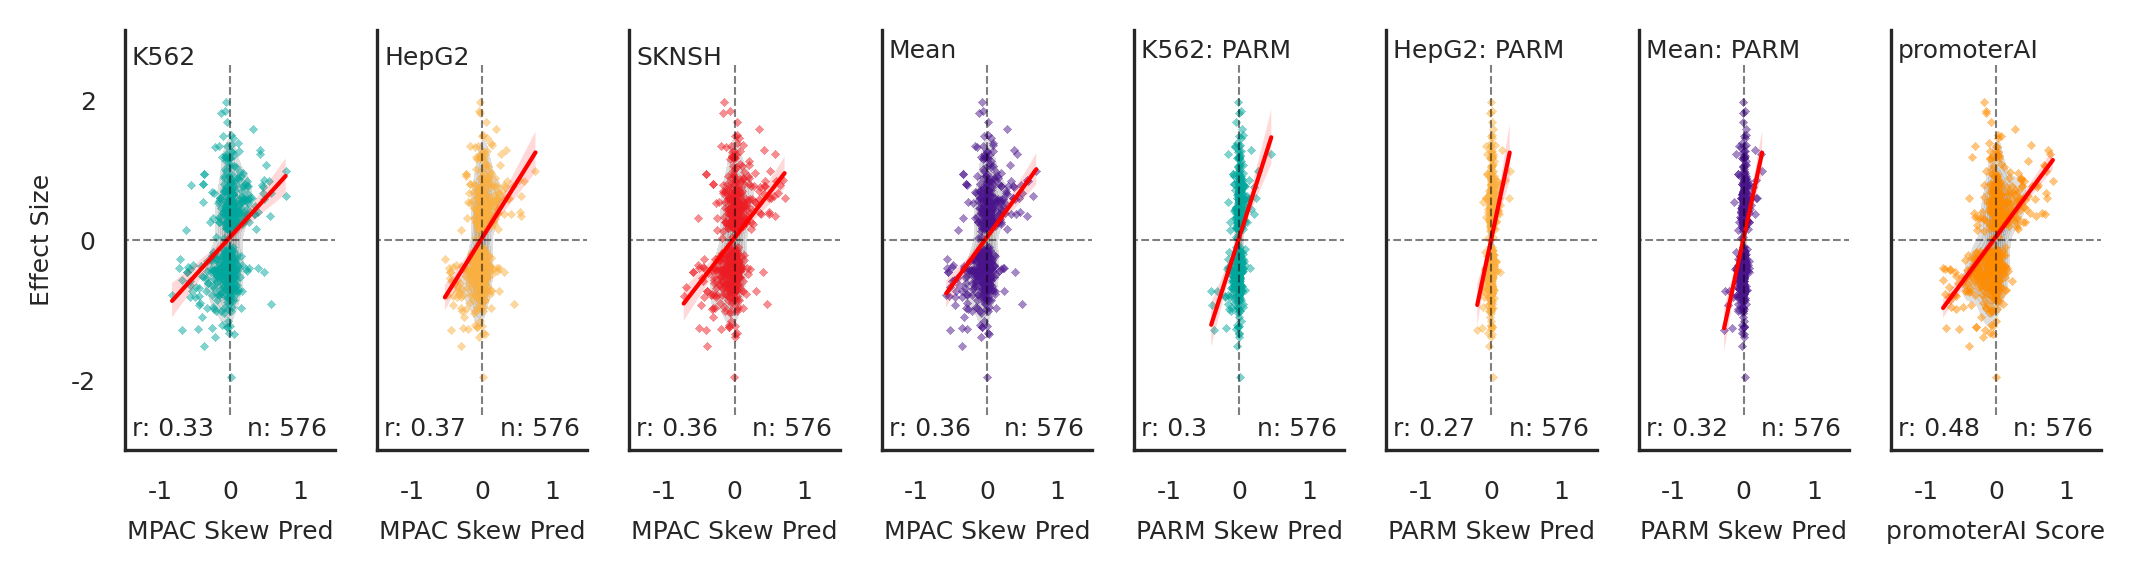

In [59]:
# plot all tissue variants
f = plt.figure(figsize=(8.5,2),dpi=300)
gs = f.add_gridspec(1,8)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# k562 #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='k562_skew_pred_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    # sns.scatterplot(data=highPIP_all_tissue_preds,
    #             x='k562_skew_pred',
    #             y='beta_posterior',
    #             linewidth=0,
    #             s=1,
    #             color='#00A79D',
    #             alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='k562_skew_pred_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=1,
                color='#00A79D',
                alpha=0.5))
    ax_01.set_ylabel('Effect Size', fontsize = 6)
    ax_01.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_01.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    ax_01.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['k562_skew_pred_tanh'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('K562', xy=(-1.4, 2.5), fontsize = 6)
# hepg2 #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='hepg2_skew_pred_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='hepg2_skew_pred_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=1,
                color='#FBB040',
                alpha=0.5))
    ax_02.set_ylabel('')
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_02.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['hepg2_skew_pred_tanh'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('HepG2', xy=(-1.4, 2.5), fontsize = 6)
# sknsh #
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_03.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='sknsh_skew_pred_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='sknsh_skew_pred_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=1,
                color='#ED1C24',
                alpha=0.5))
    ax_03.set_ylabel('')
    ax_03.tick_params(labelleft=False)
    ax_03.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_03.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['sknsh_skew_pred_tanh'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('SKNSH', xy=(-1.4, 2.5), fontsize = 6)
# mean
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[0,3], sharey=ax_01)
    ax_04.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='mpac_mean_skew_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='mpac_mean_skew_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=1,
                color='#4A148C',
                alpha=0.5))
    ax_04.set_ylabel('')
    ax_04.tick_params(labelleft=False)
    ax_04.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_04.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['mpac_mean_skew_tanh'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('Mean', xy=(-1.4, 2.6), fontsize = 6)
# k562 parm #
with sns.axes_style('white'):
    ax_05 = f.add_subplot(gs[0,4], sharey=ax_01)
    ax_05.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='parm_k562_pred_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='parm_k562_pred_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),scatter_kws=dict(s=1,
                color='#00A79D',
                alpha=0.5)
        )
    ax_05.set_ylabel('')
    ax_05.tick_params(labelleft=False)
    ax_05.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_05.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    ax_05.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_k562_pred_tanh'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('K562: PARM', xy=(-1.4, 2.6), fontsize = 6)
# hepg2 parm #
with sns.axes_style('white'):
    ax_06 = f.add_subplot(gs[0,5], sharey=ax_01)
    ax_06.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='parm_hepg2_pred_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='parm_hepg2_pred_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),scatter_kws=dict(s=1,
                color='#FBB040',
                alpha=0.5)
        )
    ax_06.set_ylabel('')
    ax_06.tick_params(labelleft=False)
    ax_06.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_06.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    ax_06.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_hepg2_pred_tanh'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('HepG2: PARM', xy=(-1.4, 2.6), fontsize = 6)
# mean parm #
with sns.axes_style('white'):
    ax_07 = f.add_subplot(gs[0,6], sharey=ax_01)
    ax_07.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='parm_mean_skew_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='parm_mean_skew_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),scatter_kws=dict(s=1,
                color='#4A148C',
                alpha=0.5)
        )
    ax_07.set_ylabel('')
    ax_07.tick_params(labelleft=False)
    ax_07.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_07.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    ax_07.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_mean_skew_tanh'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('Mean: PARM', xy=(-1.4, 2.6), fontsize = 6)
# promoterAI #
with sns.axes_style('white'):
    ax_08 = f.add_subplot(gs[0,7], sharey=ax_01)
    ax_08.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='promoterAI_score',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='promoterAI_score', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),scatter_kws=dict(s=1,
                color='darkorange',
                alpha=0.5)
        )
    ax_08.set_ylabel('')
    ax_08.tick_params(labelleft=False)
    ax_08.set_xlabel('promoterAI Score', fontsize = 6)
    ax_08.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    ax_08.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['promoterAI_score'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('promoterAI', xy=(-1.4, 2.6), fontsize = 6)
sns.despine()

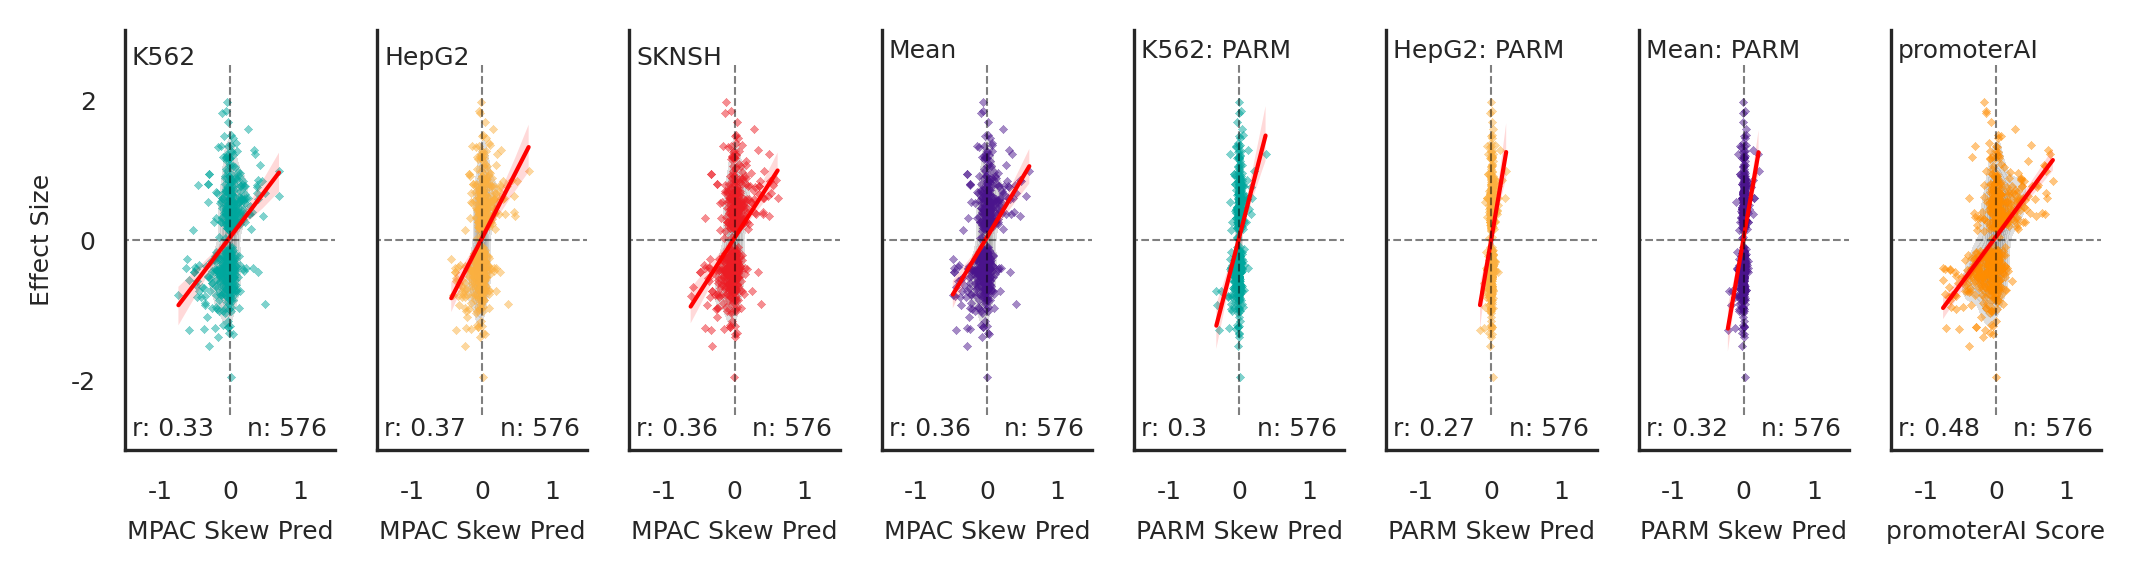

In [69]:
# plot all tissue variants
f = plt.figure(figsize=(8.5,2),dpi=300)
gs = f.add_gridspec(1,8)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# k562 #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='k562_skew_pred_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    # sns.scatterplot(data=highPIP_all_tissue_preds,
    #             x='k562_skew_pred',
    #             y='beta_posterior',
    #             linewidth=0,
    #             s=1,
    #             color='#00A79D',
    #             alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='k562_skew_pred_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=1,
                color='#00A79D',
                alpha=0.5))
    ax_01.set_ylabel('Effect Size', fontsize = 6)
    ax_01.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_01.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    ax_01.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['k562_skew_pred_tanh'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('K562', xy=(-1.4, 2.5), fontsize = 6)
# hepg2 #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='hepg2_skew_pred_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='hepg2_skew_pred_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=1,
                color='#FBB040',
                alpha=0.5))
    ax_02.set_ylabel('')
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_02.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['hepg2_skew_pred_tanh'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('HepG2', xy=(-1.4, 2.5), fontsize = 6)
# sknsh #
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_03.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='sknsh_skew_pred_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='sknsh_skew_pred_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=1,
                color='#ED1C24',
                alpha=0.5))
    ax_03.set_ylabel('')
    ax_03.tick_params(labelleft=False)
    ax_03.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_03.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['sknsh_skew_pred_tanh'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('SKNSH', xy=(-1.4, 2.5), fontsize = 6)
# mean
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[0,3], sharey=ax_01)
    ax_04.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='mpac_mean_skew_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='mpac_mean_skew_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=1,
                color='#4A148C',
                alpha=0.5))
    ax_04.set_ylabel('')
    ax_04.tick_params(labelleft=False)
    ax_04.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_04.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['mpac_mean_skew_tanh'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('Mean', xy=(-1.4, 2.6), fontsize = 6)
# k562 parm #
with sns.axes_style('white'):
    ax_05 = f.add_subplot(gs[0,4], sharey=ax_01)
    ax_05.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='parm_k562_pred_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='parm_k562_pred_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),scatter_kws=dict(s=1,
                color='#00A79D',
                alpha=0.5)
        )
    ax_05.set_ylabel('')
    ax_05.tick_params(labelleft=False)
    ax_05.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_05.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    ax_05.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_k562_pred_tanh'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('K562: PARM', xy=(-1.4, 2.6), fontsize = 6)
# hepg2 parm #
with sns.axes_style('white'):
    ax_06 = f.add_subplot(gs[0,5], sharey=ax_01)
    ax_06.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='parm_hepg2_pred_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='parm_hepg2_pred_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),scatter_kws=dict(s=1,
                color='#FBB040',
                alpha=0.5)
        )
    ax_06.set_ylabel('')
    ax_06.tick_params(labelleft=False)
    ax_06.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_06.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    ax_06.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_hepg2_pred_tanh'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('HepG2: PARM', xy=(-1.4, 2.6), fontsize = 6)
# mean parm #
with sns.axes_style('white'):
    ax_07 = f.add_subplot(gs[0,6], sharey=ax_01)
    ax_07.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='parm_mean_skew_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='parm_mean_skew_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),scatter_kws=dict(s=1,
                color='#4A148C',
                alpha=0.5)
        )
    ax_07.set_ylabel('')
    ax_07.tick_params(labelleft=False)
    ax_07.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_07.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    ax_07.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_mean_skew_tanh'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('Mean: PARM', xy=(-1.4, 2.6), fontsize = 6)
# promoterAI #
with sns.axes_style('white'):
    ax_08 = f.add_subplot(gs[0,7], sharey=ax_01)
    ax_08.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='promoterAI_score',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='promoterAI_score', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),scatter_kws=dict(s=1,
                color='darkorange',
                alpha=0.5)
        )
    ax_08.set_ylabel('')
    ax_08.tick_params(labelleft=False)
    ax_08.set_xlabel('promoterAI Score', fontsize = 6)
    ax_08.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    ax_08.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['promoterAI_score'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('promoterAI', xy=(-1.4, 2.6), fontsize = 6)
sns.despine()

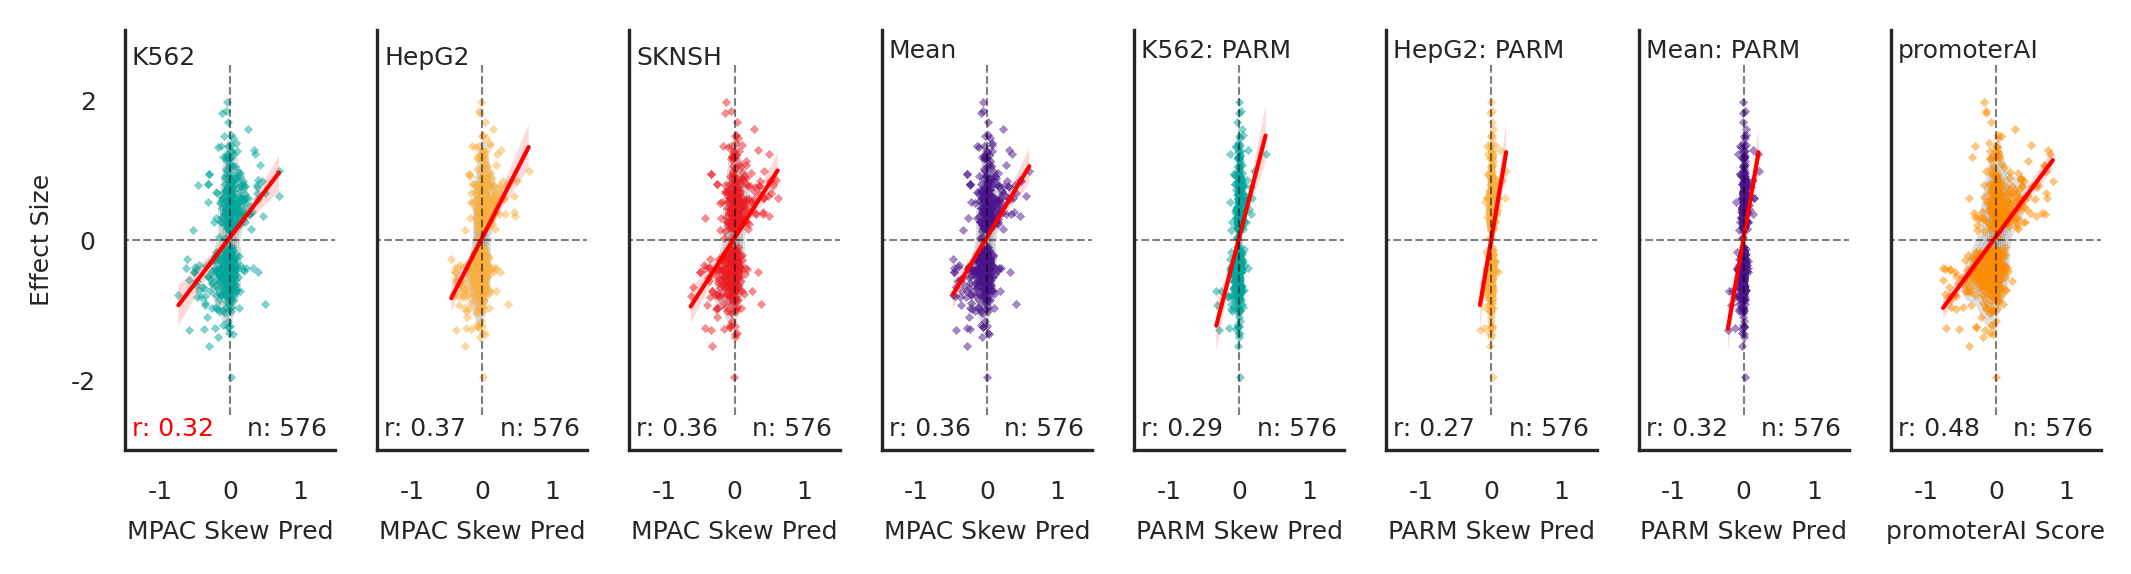

In [71]:
# plot all tissue variants
f = plt.figure(figsize=(8.5,2),dpi=300)
gs = f.add_gridspec(1,8)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# k562 #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='k562_skew_pred_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    # sns.scatterplot(data=highPIP_all_tissue_preds,
    #             x='k562_skew_pred',
    #             y='beta_posterior',
    #             linewidth=0,
    #             s=1,
    #             color='#00A79D',
    #             alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='k562_skew_pred_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=1,
                color='#00A79D',
                alpha=0.5))
    ax_01.set_ylabel('Effect Size', fontsize = 6)
    ax_01.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_01.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    ax_01.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.spearmanr(highPIP_all_tissue_preds['k562_skew_pred_tanh'], 
                                             highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6, color = 'r')
    plt.annotate('K562', xy=(-1.4, 2.5), fontsize = 6)
# hepg2 #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='hepg2_skew_pred_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='hepg2_skew_pred_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=1,
                color='#FBB040',
                alpha=0.5))
    ax_02.set_ylabel('')
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_02.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.spearmanr(highPIP_all_tissue_preds['hepg2_skew_pred_tanh'], 
                                            highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('HepG2', xy=(-1.4, 2.5), fontsize = 6)
# sknsh #
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_03.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='sknsh_skew_pred_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='sknsh_skew_pred_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=1,
                color='#ED1C24',
                alpha=0.5))
    ax_03.set_ylabel('')
    ax_03.tick_params(labelleft=False)
    ax_03.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_03.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.spearmanr(highPIP_all_tissue_preds['sknsh_skew_pred_tanh'], 
                                             highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('SKNSH', xy=(-1.4, 2.5), fontsize = 6)
# mean
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[0,3], sharey=ax_01)
    ax_04.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='mpac_mean_skew_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='mpac_mean_skew_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=1,
                color='#4A148C',
                alpha=0.5))
    ax_04.set_ylabel('')
    ax_04.tick_params(labelleft=False)
    ax_04.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_04.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.spearmanr(highPIP_all_tissue_preds['mpac_mean_skew_tanh'], 
                                             highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('Mean', xy=(-1.4, 2.6), fontsize = 6)
# k562 parm #
with sns.axes_style('white'):
    ax_05 = f.add_subplot(gs[0,4], sharey=ax_01)
    ax_05.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='parm_k562_pred_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='parm_k562_pred_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),scatter_kws=dict(s=1,
                color='#00A79D',
                alpha=0.5)
        )
    ax_05.set_ylabel('')
    ax_05.tick_params(labelleft=False)
    ax_05.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_05.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    ax_05.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.spearmanr(highPIP_all_tissue_preds['parm_k562_pred_tanh'], 
                                             highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('K562: PARM', xy=(-1.4, 2.6), fontsize = 6)
# hepg2 parm #
with sns.axes_style('white'):
    ax_06 = f.add_subplot(gs[0,5], sharey=ax_01)
    ax_06.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='parm_hepg2_pred_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='parm_hepg2_pred_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),scatter_kws=dict(s=1,
                color='#FBB040',
                alpha=0.5)
        )
    ax_06.set_ylabel('')
    ax_06.tick_params(labelleft=False)
    ax_06.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_06.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    ax_06.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_hepg2_pred_tanh'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('HepG2: PARM', xy=(-1.4, 2.6), fontsize = 6)
# mean parm #
with sns.axes_style('white'):
    ax_07 = f.add_subplot(gs[0,6], sharey=ax_01)
    ax_07.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='parm_mean_skew_tanh',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='parm_mean_skew_tanh', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),scatter_kws=dict(s=1,
                color='#4A148C',
                alpha=0.5)
        )
    ax_07.set_ylabel('')
    ax_07.tick_params(labelleft=False)
    ax_07.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_07.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    ax_07.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_mean_skew_tanh'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('Mean: PARM', xy=(-1.4, 2.6), fontsize = 6)
# promoterAI #
with sns.axes_style('white'):
    ax_08 = f.add_subplot(gs[0,7], sharey=ax_01)
    ax_08.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='promoterAI_score',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.regplot(data=highPIP_all_tissue_preds, x='promoterAI_score', y='beta_posterior',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),scatter_kws=dict(s=1,
                color='darkorange',
                alpha=0.5)
        )
    ax_08.set_ylabel('')
    ax_08.tick_params(labelleft=False)
    ax_08.set_xlabel('promoterAI Score', fontsize = 6)
    ax_08.set_xticks([-1, 0, 1], [-1, 0, 1], fontsize = 6)
    ax_08.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-1.5, 1.5))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['promoterAI_score'], 
                                            y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-1.4, -2.8), fontsize = 6)
    plt.annotate('promoterAI', xy=(-1.4, 2.6), fontsize = 6)
sns.despine()

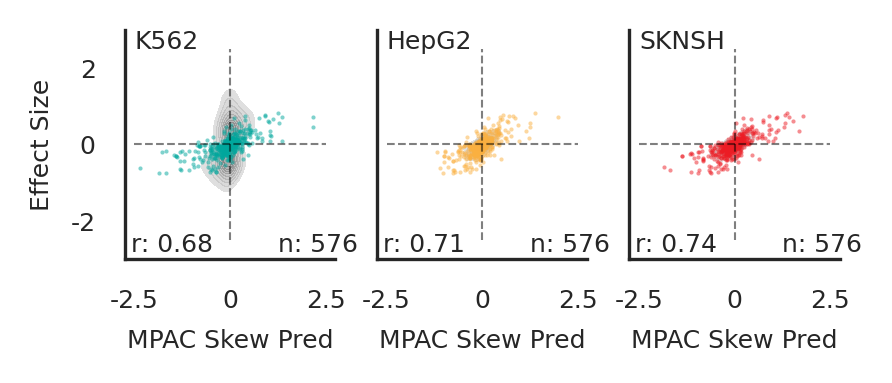

In [117]:
# plot all tissue variants
f = plt.figure(figsize=(8.5,2),dpi=300)
gs = f.add_gridspec(1,8)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# k562 #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='k562_skew_pred',
                y='beta_posterior',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=highPIP_all_tissue_preds,
                x='k562_skew_pred',
                y='promoterAI_score',
                linewidth=0,
                s=1,
                color='#00A79D',
                alpha=0.5)
    ax_01.set_ylabel('Effect Size', fontsize = 6)
    ax_01.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_01.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_01.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['k562_skew_pred'], 
                                            y=highPIP_all_tissue_preds['promoterAI_score'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('K562', xy=(-2.5, 2.5), fontsize = 6)
# hepg2 #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='hepg2_skew_pred',
                y='promoterAI_score',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=highPIP_all_tissue_preds,
                x='hepg2_skew_pred',
                y='promoterAI_score',
                linewidth=0,
                s=1,
                color='#FBB040',
                alpha=0.5,)
    ax_02.set_ylabel('')
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_02.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['hepg2_skew_pred'], 
                                            y=highPIP_all_tissue_preds['promoterAI_score'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('HepG2', xy=(-2.5, 2.5), fontsize = 6)
# sknsh #
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_03.set_aspect('equal')
    sns.kdeplot(data=highPIP_all_tissue_preds,
                x='sknsh_skew_pred',
                y='promoterAI_score',
                fill=True,
                color='gray',
                thresh=.2,
                alpha=0.5)
    sns.scatterplot(data=highPIP_all_tissue_preds,
                x='sknsh_skew_pred',
                y='promoterAI_score',
                linewidth=0,
                s=1,
                color='#ED1C24',
                alpha=0.5,)
    ax_03.set_ylabel('')
    ax_03.tick_params(labelleft=False)
    ax_03.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_03.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['sknsh_skew_pred'], 
                                            y=highPIP_all_tissue_preds['promoterAI_score'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('SKNSH', xy=(-2.5, 2.5), fontsize = 6)
# # mean
# with sns.axes_style('white'):
#     ax_04 = f.add_subplot(gs[0,3], sharey=ax_01)
#     ax_04.set_aspect('equal')
#     sns.kdeplot(data=highPIP_all_tissue_preds,
#                 x='mpac_mean_skew',
#                 y='beta_posterior',
#                 fill=True,
#                 color='gray',
#                 thresh=.2,
#                 alpha=0.5)
#     sns.scatterplot(data=highPIP_all_tissue_preds,
#                 x='mpac_mean_skew',
#                 y='beta_posterior',
#                 linewidth=0,
#                 s=1,
#                 color='#4A148C',
#                 alpha=0.5,)
#     ax_04.set_ylabel('')
#     ax_04.tick_params(labelleft=False)
#     ax_04.set_xlabel('MPAC Skew Pred', fontsize = 6)
#     ax_04.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
#     plt.xlim((-2.75, 2.75))
#     plt.ylim((-3, 3))
#     plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
#     plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
#     plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
#     plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['mpac_mean_skew'], 
#                                             y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
#     plt.annotate('Mean', xy=(-2.5, 2.5), fontsize = 6)
# # k562 parm #
# with sns.axes_style('white'):
#     ax_05 = f.add_subplot(gs[0,4], sharey=ax_01)
#     ax_05.set_aspect('equal')
#     sns.kdeplot(data=highPIP_all_tissue_preds,
#                 x='parm_k562_pred',
#                 y='beta_posterior',
#                 fill=True,
#                 color='gray',
#                 thresh=.2,
#                 alpha=0.5)
#     sns.scatterplot(data=highPIP_all_tissue_preds,
#                 x='parm_k562_pred',
#                 y='beta_posterior',
#                 linewidth=0,
#                 s=1,
#                 color='#00A79D',
#                 alpha=0.5)
#     ax_05.set_ylabel('')
#     ax_05.tick_params(labelleft=False)
#     ax_05.set_xlabel('PARM Skew Pred', fontsize = 6)
#     ax_05.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
#     ax_05.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
#     plt.xlim((-2.75, 2.75))
#     plt.ylim((-3, 3))
#     plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
#     plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
#     plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
#     plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_k562_pred'], 
#                                             y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
#     plt.annotate('K562: PARM', xy=(-2.5, 2.5), fontsize = 6)
# # hepg2 parm #
# with sns.axes_style('white'):
#     ax_06 = f.add_subplot(gs[0,5], sharey=ax_01)
#     ax_06.set_aspect('equal')
#     sns.kdeplot(data=highPIP_all_tissue_preds,
#                 x='parm_hepg2_pred',
#                 y='beta_posterior',
#                 fill=True,
#                 color='gray',
#                 thresh=.2,
#                 alpha=0.5)
#     sns.scatterplot(data=highPIP_all_tissue_preds,
#                 x='parm_hepg2_pred',
#                 y='beta_posterior',
#                 linewidth=0,
#                 s=1,
#                 color='#FBB040',
#                 alpha=0.5)
#     ax_06.set_ylabel('')
#     ax_06.tick_params(labelleft=False)
#     ax_06.set_xlabel('PARM Skew Pred', fontsize = 6)
#     ax_06.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
#     ax_06.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
#     plt.xlim((-2.75, 2.75))
#     plt.ylim((-3, 3))
#     plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
#     plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
#     plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
#     plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_hepg2_pred'], 
#                                             y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
#     plt.annotate('HepG2: PARM', xy=(-2.5, 2.5), fontsize = 6)
# # mean parm #
# with sns.axes_style('white'):
#     ax_07 = f.add_subplot(gs[0,6], sharey=ax_01)
#     ax_07.set_aspect('equal')
#     sns.kdeplot(data=highPIP_all_tissue_preds,
#                 x='parm_mean_skew',
#                 y='beta_posterior',
#                 fill=True,
#                 color='gray',
#                 thresh=.2,
#                 alpha=0.5)
#     sns.scatterplot(data=highPIP_all_tissue_preds,
#                 x='parm_mean_skew',
#                 y='beta_posterior',
#                 linewidth=0,
#                 s=1,
#                 color='#4A148C',
#                 alpha=0.5)
#     ax_07.set_ylabel('')
#     ax_07.tick_params(labelleft=False)
#     ax_07.set_xlabel('PARM Skew Pred', fontsize = 6)
#     ax_07.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
#     ax_07.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
#     plt.xlim((-2.75, 2.75))
#     plt.ylim((-3, 3))
#     plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
#     plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
#     plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
#     plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_mean_skew'], 
#                                             y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
#     plt.annotate('Mean: PARM', xy=(-2.5, 2.5), fontsize = 6)
# # promoterAI #
# with sns.axes_style('white'):
#     ax_08 = f.add_subplot(gs[0,7], sharey=ax_01)
#     ax_08.set_aspect('equal')
#     sns.kdeplot(data=highPIP_all_tissue_preds,
#                 x='promoterAI_score',
#                 y='beta_posterior',
#                 fill=True,
#                 color='gray',
#                 thresh=.2,
#                 alpha=0.5)
#     sns.scatterplot(data=highPIP_all_tissue_preds,
#                 x='promoterAI_score',
#                 y='beta_posterior',
#                 linewidth=0,
#                 s=1,
#                 color='darkorange',
#                 alpha=0.5)
#     ax_08.set_ylabel('')
#     ax_08.tick_params(labelleft=False)
#     ax_08.set_xlabel('promoterAI Score', fontsize = 6)
#     ax_08.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
#     ax_08.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
#     plt.xlim((-2.75, 2.75))
#     plt.ylim((-3, 3))
#     plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
#     plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
#     plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
#     plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['promoterAI_score'], 
#                                             y=highPIP_all_tissue_preds['beta_posterior'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
#     plt.annotate('promoterAI', xy=(-2.5, 2.5), fontsize = 6)
sns.despine()

In [91]:
highPIP_all_tissue_preds

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,parm_hepg2_emVar,parm_emVar_any,mpac_mean_skew,mpac_max_skew,parm_max_skew,parm_mean_skew,var_id,phyloP_470,gtex_id,beta_posterior
